# (02) gaussian-exp, vH16: (16, 16.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['latent_act'] = 'exp'
cfg_vae['clamp_u'] = (3.0, 2.3)
cfg_vae['clamp_du'] = (3.0, 3.0)

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 16.0

cfg_tr['lr'] = 1e-4

cfg_tr['epochs'] = 600

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

gaussian_exp_vH16_t-16_z-[512]_u-(3,2.3),du-(3,3)_<grad|lin>
b200-ep600-lr(0.0001)_beta(16:0.1)_gr(500)_(2025_03_03,22:02)

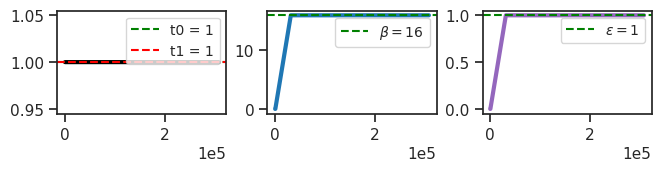

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [8]:
tr.model.layer.u_init[1].data.fill_(-1.5)

tensor([[-1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000,
         -1.5000, -1.5000, -

In [10]:
tr.n_iters

309000

In [11]:
print(tr.model.layer)

GaussianExpLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [ ]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 69, avg loss: 83830854790252880.000:  12%| | 69/600 [25:08<3:13:28, 21.8

epoch # 300, avg loss: 268.181: 100%|███████| 300/300 [3:38:53<00:00, 43.78s/it]


In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.2508], device='cuda:3', grad_fn=<ExpBackward0>),
 tensor([0.0211], device='cuda:3', grad_fn=<ExpBackward0>))

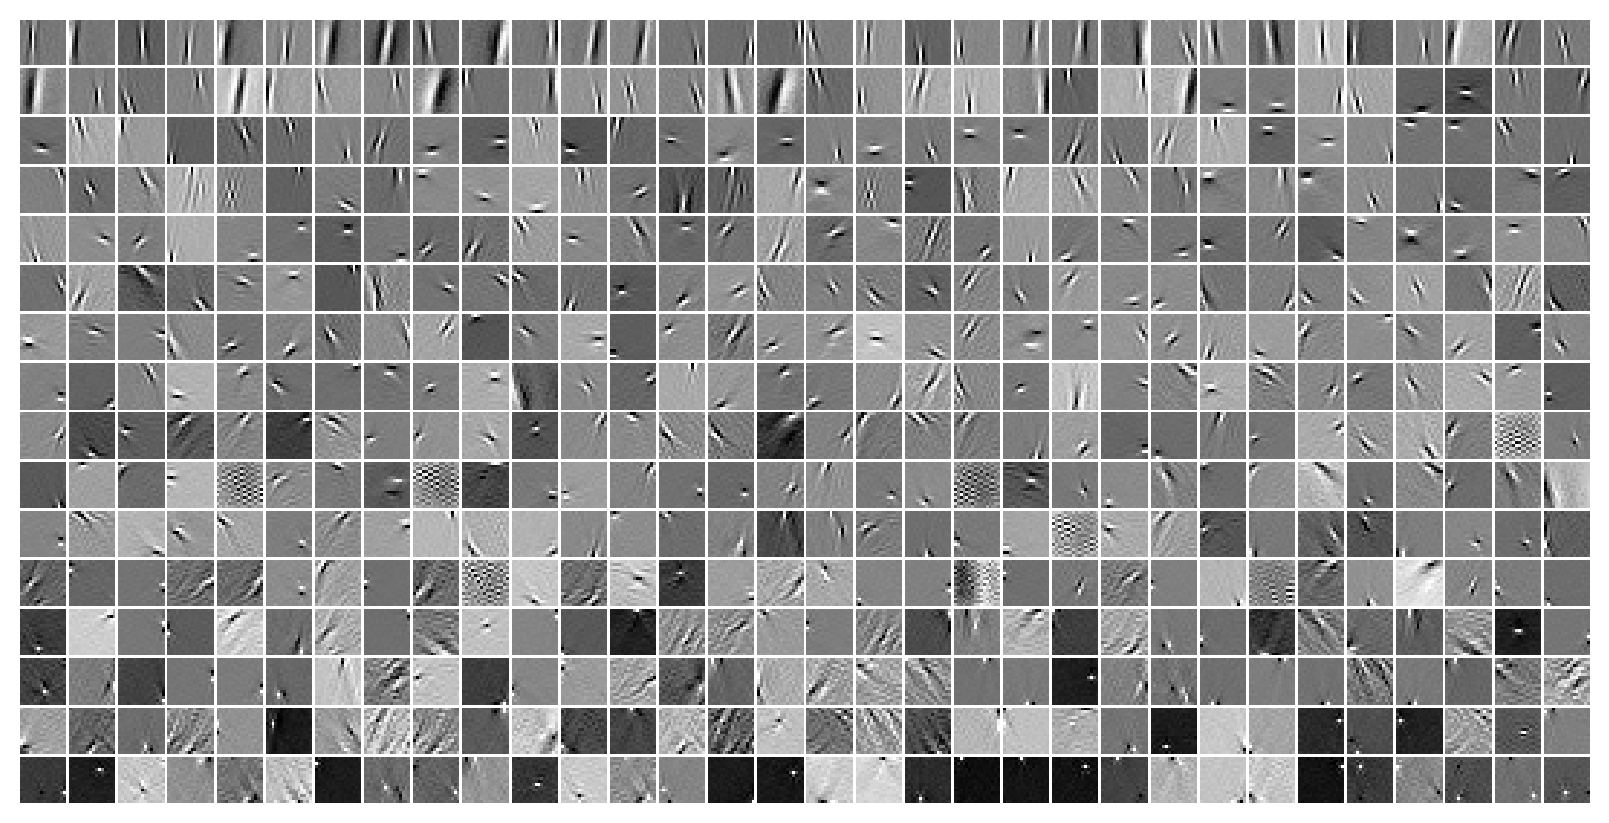

In [8]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

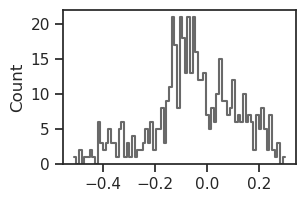

In [10]:
histplot(u0, bins=80, color='dimgrey');

In [11]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

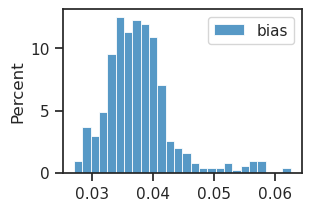

In [12]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

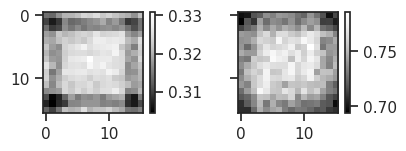

In [13]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:46<00:00, 23.07s/it]


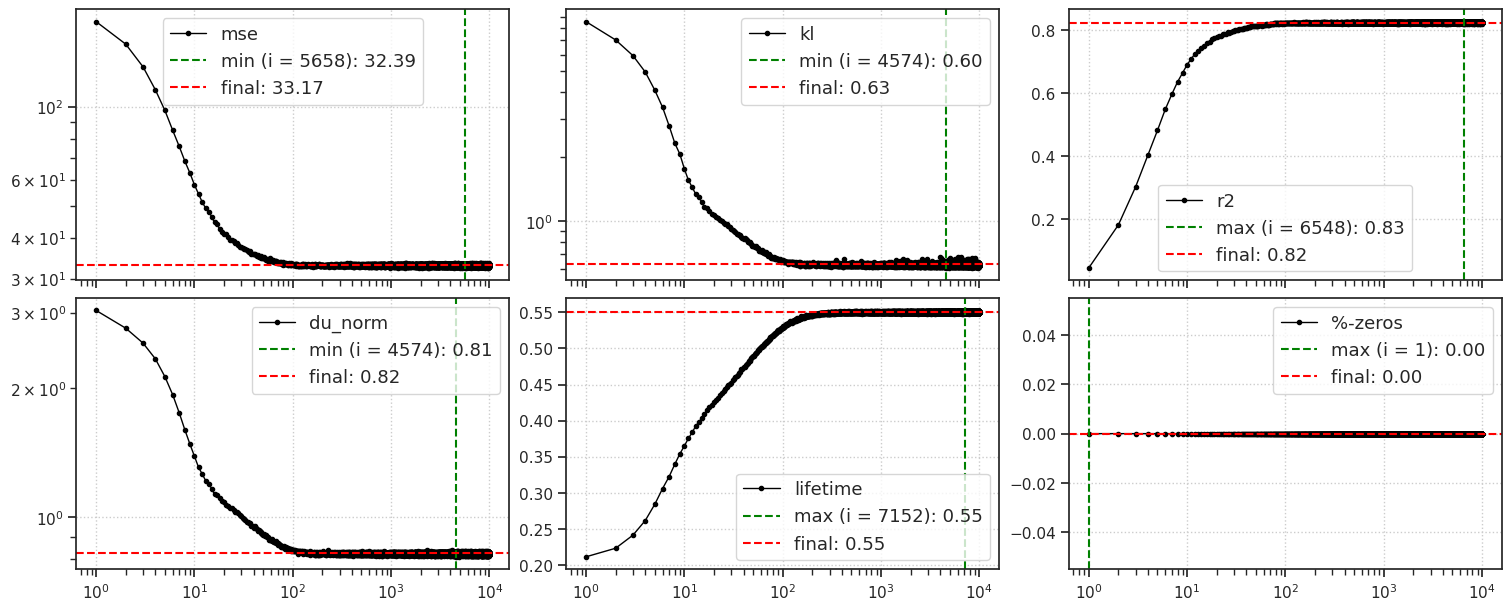

CPU times: user 1min 2s, sys: 22.3 s, total: 1min 24s
Wall time: 1min 24s


In [14]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:40<00:00, 20.40s/it]


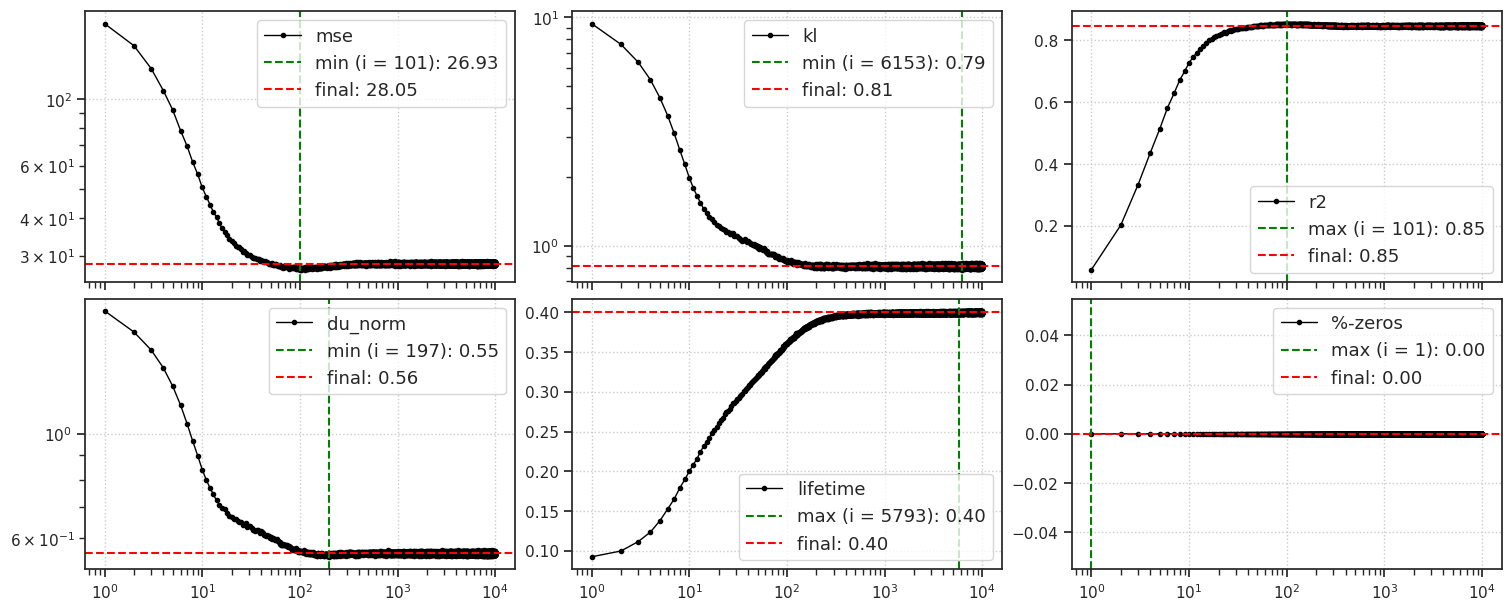

CPU times: user 55.5 s, sys: 8.65 s, total: 1min 4s
Wall time: 1min 4s


In [13]:
### Was: w/o Fisher

100%|███████████████████████████████████| 2/2 [01:02<00:00, 31.11s/it]


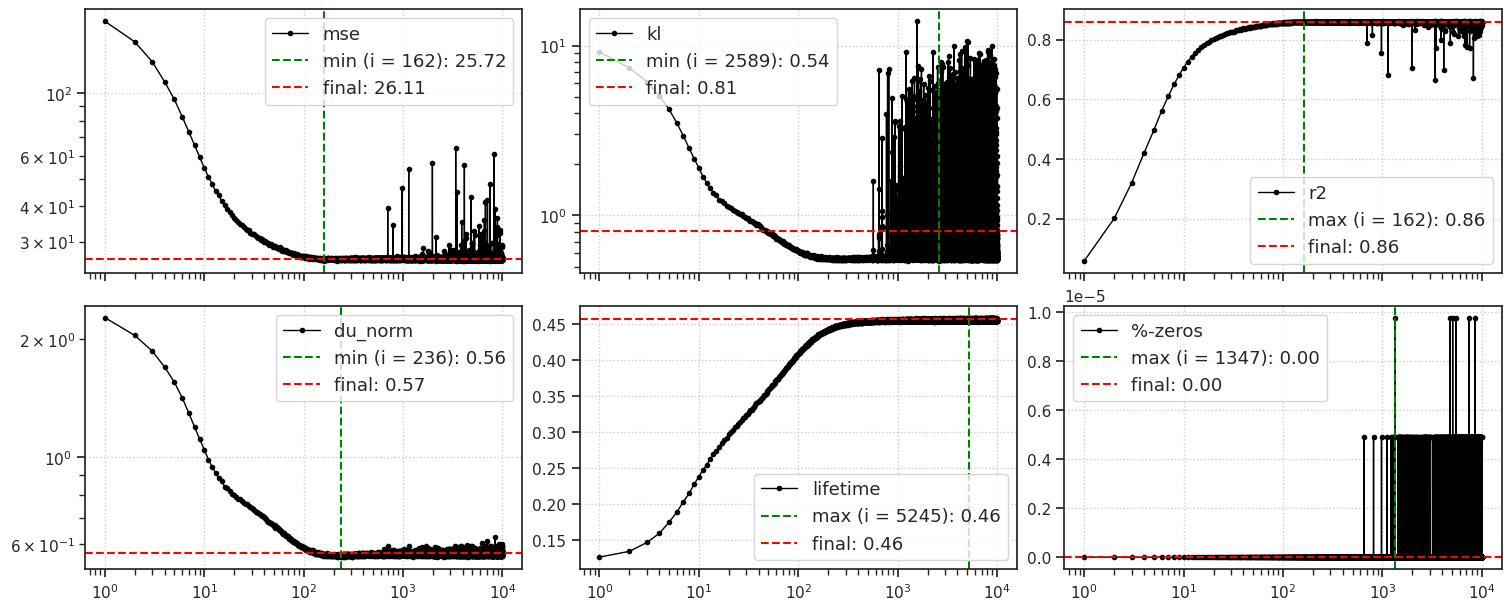

CPU times: user 1min 3s, sys: 1min 29s, total: 2min 32s
Wall time: 2min 32s


In [16]:
### Was: w/ Fisher